# 04 — Régression OLS sur les dépenses pharmaceutiques 2016–2025

**Objectif** : expliquer et quantifier les facteurs qui influencent le montant remboursé  
par classe thérapeutique et par année.

**Variable dépendante (Y)** : montant total remboursé (`rem`)  
**Variables explicatives (X)** : année, volume de boîtes, classe ATC1

---

## 0. Imports et chargement

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROJECT_DIR  = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
CLEAN_DIR    = PROJECT_DIR / 'data' / 'clean'
OUTPUTS_DIR  = PROJECT_DIR / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)

print('Projet  :', PROJECT_DIR)
print('Clean   :', CLEAN_DIR)
print('Outputs :', OUTPUTS_DIR)

Projet  : c:\Users\Enes\projet_pharma
Clean   : c:\Users\Enes\projet_pharma\data\clean
Outputs : c:\Users\Enes\projet_pharma\outputs


In [16]:
def parse_euro(series):
    return (
        series.astype(str).str.strip()
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .replace('', '0').astype(float)
    )

def load_year(annee, data_dir):
    for pattern in [f'OPEN_MEDIC_{annee}.zip', f'OPEN_MEDIC_{annee}.csv']:
        path = data_dir / pattern
        if path.exists():
            break
    else:
        return None
    df = pd.read_csv(path, sep=None, engine='python', encoding='latin-1')
    df.columns = df.columns.str.lower().str.strip()
    for col in ['l_atc1', 'l_atc2', 'l_atc3', 'l_atc4', 'l_atc5', 'l_cip13']:
        if col not in df.columns:
            df[col] = ''
    for col in ['rem', 'bse']:
        df[col] = parse_euro(df[col])
    df['annee'] = annee
    return df

# Essaie d'abord le fichier nettoyé, sinon recharge depuis les zips
clean_file = CLEAN_DIR / 'open_medic_2025_clean.csv'
raw_dir    = PROJECT_DIR / 'data' / 'raw'
data_dir   = Path('C:/Users/Enes/data')  # dossier source

frames = []
for annee in range(2016, 2026):
    df = load_year(annee, data_dir)
    if df is not None:
        frames.append(df)
        print(f'[{annee}] {df.shape[0]:,} lignes')

df_raw = pd.concat(frames, ignore_index=True)
print(f'\nTotal : {df_raw.shape[0]:,} lignes')

[2016] 1,799,650 lignes
[2017] 1,806,702 lignes
[2018] 1,815,551 lignes
[2019] 1,836,084 lignes
[2020] 1,819,396 lignes
[2021] 1,820,538 lignes
[2022] 1,873,493 lignes
[2023] 1,926,164 lignes
[2024] 1,916,885 lignes
[2025] 2,430,616 lignes

Total : 19,045,079 lignes


---
## 1. Préparation des variables

On agrège par **année × classe ATC1** pour obtenir une observation par combinaison.  
Chaque ligne représente le total remboursé pour une classe thérapeutique une année donnée.

In [17]:
# Agrégation : une ligne = (annee, classe ATC1)
df_ols = (
    df_raw[df_raw['l_atc1'] != '']
    .groupby(['annee', 'l_atc1'])
    .agg(
        rem_total   = ('rem',    'sum'),
        boites_total= ('boites', 'sum')
    )
    .reset_index()
)

print(f'Dataset OLS : {df_ols.shape[0]} observations × {df_ols.shape[1]} variables')
print(f'Classes ATC1 : {df_ols["l_atc1"].nunique()}')
print(f'Années : {sorted(df_ols["annee"].unique())}')
df_ols.head(8)

Dataset OLS : 140 observations × 4 variables
Classes ATC1 : 45
Années : [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,annee,l_atc1,rem_total,boites_total
0,2016,Anti-infectieux (usage systémiq,2.069863e+09,161098375
1,2016,Antinéoplasiques et agents immu,3.581424e+09,15048714
2,2016,"Antiparasitaires, insecticides",5.218738e+07,7341616
3,2016,Dermatologie,2.110961e+08,87672808
4,2016,Divers,3.248939e+08,8183586
5,2016,"Hormones systémiques, à l exclu",5.769188e+08,74845583
6,2016,Organes sensoriels,9.182873e+08,76500903
7,2016,Sang et organes hématopoiétique,1.509864e+09,117741301


In [18]:
# Variables dummies pour ATC1 (drop_first pour éviter la multicolinéarité)
dummies_atc = pd.get_dummies(df_ols['l_atc1'], prefix='ATC', drop_first=True)

# Assemblage du dataset final
df_model = pd.concat([
    df_ols[['annee', 'boites_total', 'rem_total']],
    dummies_atc
], axis=1)

# Retire les lignes avec NaN ou valeurs nulles
df_model = df_model.dropna()
df_model = df_model[df_model['rem_total'] > 0]

print(f'Observations finales : {len(df_model)}')
print(f'Variables dummies ATC : {dummies_atc.shape[1]}')
print(f'Total variables X : {df_model.shape[1] - 1}')
df_model.head(3)

Observations finales : 140
Variables dummies ATC : 44
Total variables X : 46


,annee,boites_total,rem_total,ATC_ANTINEOPLASIQUES ET AGENTS IMMUNOMODULANTS,"ATC_ANTIPARASITAIRES, INSECTICIDES ET REPULSIFS",ATC_Anti-infectieux (usage systmique),ATC_Anti-infectieux (usage systémiq,ATC_Anti-infectieux (usage systémique),ATC_Antinoplasiques et agents immunomodulants,ATC_Antinéoplasiques et agents immu,...,ATC_Systme musculo-squelettique,ATC_Systme nerveux,ATC_Systme respiratoire,ATC_Système cardio-vasculaire,ATC_Système digestif et métabolisme,ATC_Système génito-urinaire et horm,ATC_Système génito-urinaire et hormones sexuelles,ATC_Système musculo-squelettique,ATC_Système nerveux,ATC_Système respiratoire
0,2016,161098375,2.069863e+09,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2016,15048714,3.581424e+09,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,2016,7341616,5.218738e+07,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


---
## 2. Régression simple : Remboursement ~ Année

On commence par une régression simple pour mesurer la **tendance temporelle** :  
de combien augmentent les dépenses chaque année, toutes choses égales par ailleurs ?

In [19]:
Y       = df_model['rem_total']
X_simple= sm.add_constant(df_model[['annee']])

model_simple = sm.OLS(Y, X_simple).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:              rem_total   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     2.825
Date:                Fri, 03 Jul 2026   Prob (F-statistic):             0.0951
Time:                        15:22:33   Log-Likelihood:                -3157.3
No. Observations:                 140   AIC:                             6319.
Df Residuals:                     138   BIC:                             6324.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.501e+11   9.02e+10     -1.664      0.0

In [20]:
coef_annee = model_simple.params['annee']
r2_simple  = model_simple.rsquared
pval_annee = model_simple.pvalues['annee']

print('=== INTERPRÉTATION — Régression simple ===')
print(f"Coefficient année : {coef_annee:,.0f} €")
print(f"  → Chaque année supplémentaire est associée à une variation")
print(f"    de {coef_annee:+,.0f} € de remboursement par classe ATC.")
print(f"P-value : {pval_annee:.4f} {'✓ significatif (< 0.05)' if pval_annee < 0.05 else '✗ non significatif'}")
print(f"R² : {r2_simple:.4f} → l'année explique {r2_simple*100:.1f}% de la variance des remboursements.")

=== INTERPRÉTATION — Régression simple ===
Coefficient année : 75,045,639 €
  → Chaque année supplémentaire est associée à une variation
    de +75,045,639 € de remboursement par classe ATC.
P-value : 0.0951 ✗ non significatif
R² : 0.0201 → l'année explique 2.0% de la variance des remboursements.


---
## 3. Régression multiple : Remboursement ~ Année + Boîtes + Classes ATC

On ajoute le **volume de boîtes** (proxy de la demande)  
et les **dummies ATC** pour contrôler les effets fixes par classe thérapeutique.

In [21]:
X_cols  = ['annee', 'boites_total'] + [c for c in df_model.columns if c.startswith('ATC_')]

# Conversion explicite en float (les dummies bool causent une erreur statsmodels)
X_multi = sm.add_constant(df_model[X_cols].astype(float))
Y       = df_model['rem_total'].astype(float)

model_multi = sm.OLS(Y, X_multi).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:              rem_total   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     150.6
Date:                Fri, 03 Jul 2026   Prob (F-statistic):           1.74e-70
Time:                        15:22:33   Log-Likelihood:                -2856.0
No. Observations:                 140   AIC:                             5806.
Df Residuals:                      93   BIC:                             5944.
Df Model:                          46                                         
Covariance Type:            nonrobust                                         
                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [22]:
# Variables significatives (p-value < 0.05)
resultats = pd.DataFrame({
    'coef'    : model_multi.params,
    'std_err' : model_multi.bse,
    't_stat'  : model_multi.tvalues,
    'p_value' : model_multi.pvalues,
}).round(6)

resultats['significatif'] = resultats['p_value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
)

sig = resultats[resultats['p_value'] < 0.05].sort_values('p_value')
print(f'Variables significatives (p < 0.05) : {len(sig)} / {len(resultats)}')
print()
print(sig.to_string())

Variables significatives (p < 0.05) : 27 / 47

                                                           coef       std_err     t_stat   p_value significatif
ATC_ANTINEOPLASIQUES ET AGENTS IMMUNOMODULANTS     6.194413e+09  4.751725e+08  13.036136  0.000000          ***
ATC_Antinéoplasiques et agents immunomodulants     4.215312e+09  4.988646e+08   8.449811  0.000000          ***
ATC_Antinéoplasiques et agents immu                3.046353e+09  5.566531e+08   5.472623  0.000000          ***
ATC_Antinoplasiques et agents immunomodulants     7.258253e+09  4.923810e+08  14.741130  0.000000          ***
ATC_Système musculo-squelettique                  -1.127717e+09  2.603557e+08  -4.331447  0.000037          ***
ATC_Système respiratoire                          -7.029980e+08  1.686023e+08  -4.169563  0.000068          ***
ATC_SYSTEME MUSCULO-SQUELETTIQUE                  -1.076500e+09  2.824501e+08  -3.811294  0.000248          ***
ATC_Dermatologie                                  -1.0474

In [23]:
r2_multi = model_multi.rsquared
r2_adj   = model_multi.rsquared_adj

print('=== INTERPRÉTATION — Régression multiple ===')
print(f"R²          : {r2_multi:.4f}  → le modèle explique {r2_multi*100:.1f}% de la variance")
print(f"R² ajusté   : {r2_adj:.4f}")
print(f"Gain vs régression simple : +{(r2_multi - r2_simple)*100:.1f} points")
print()
if 'boites_total' in model_multi.params:
    coef_boites = model_multi.params['boites_total']
    pval_boites = model_multi.pvalues['boites_total']
    print(f"Coef. boîtes  : {coef_boites:.4f} €/boîte")
    print(f"  → 1 boîte supplémentaire est associée à {coef_boites:.2f} € de remboursement.")
    print(f"  P-value : {pval_boites:.4f} {'✓' if pval_boites < 0.05 else '✗'}")

=== INTERPRÉTATION — Régression multiple ===
R²          : 0.9868  → le modèle explique 98.7% de la variance
R² ajusté   : 0.9802
Gain vs régression simple : +96.7 points

Coef. boîtes  : 9.9689 €/boîte
  → 1 boîte supplémentaire est associée à 9.97 € de remboursement.
  P-value : 0.0036 ✓


---
## 4. Diagnostics du modèle

On vérifie les **hypothèses classiques** de la régression OLS :
- **Résidus centrés** : les erreurs doivent être aléatoires (pas de structure)
- **Normalité** : les résidus doivent suivre une loi normale (QQ-plot)
- **Homoscédasticité** : la variance des résidus doit être constante (test Breusch-Pagan)

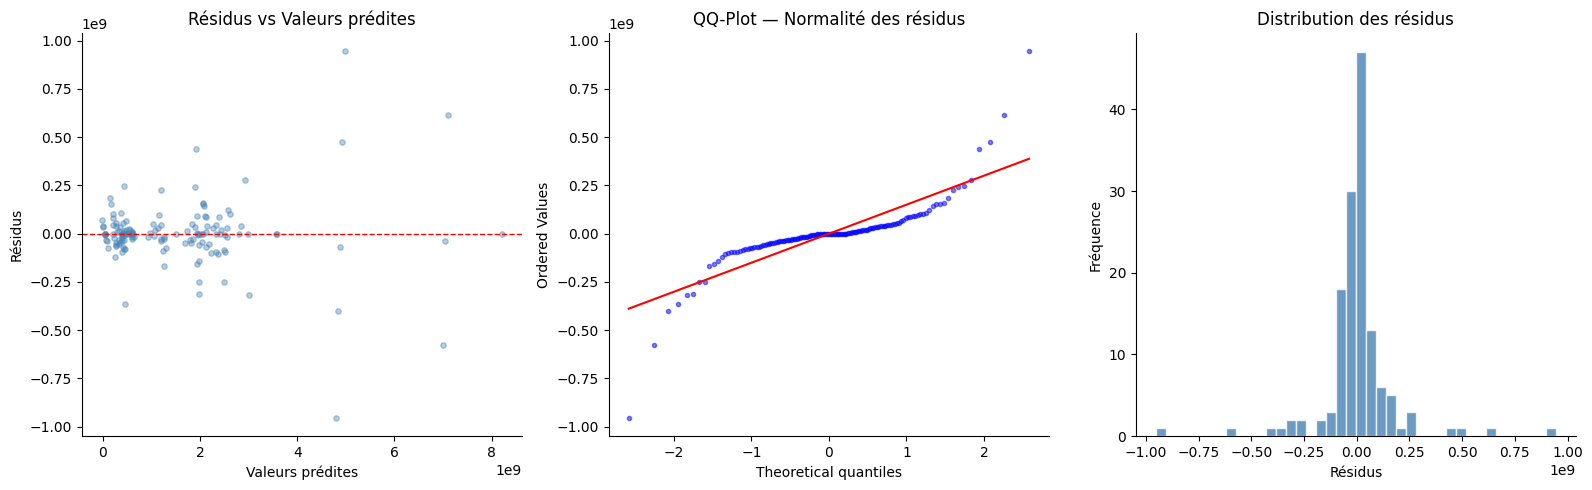

In [24]:
residus    = model_multi.resid
predictions= model_multi.fittedvalues

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# --- Graphique 1 : Résidus vs Valeurs prédites ---
ax1 = fig.add_subplot(gs[0])
ax1.scatter(predictions, residus, alpha=0.4, s=15, color='steelblue')
ax1.axhline(0, color='red', linewidth=1, linestyle='--')
ax1.set_xlabel('Valeurs prédites')
ax1.set_ylabel('Résidus')
ax1.set_title('Résidus vs Valeurs prédites')

# --- Graphique 2 : QQ-plot ---
ax2 = fig.add_subplot(gs[1])
stats.probplot(residus, dist='norm', plot=ax2)
ax2.set_title('QQ-Plot — Normalité des résidus')
ax2.get_lines()[0].set(markersize=3, alpha=0.5)

# --- Graphique 3 : Distribution des résidus ---
ax3 = fig.add_subplot(gs[2])
ax3.hist(residus, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax3.set_xlabel('Résidus')
ax3.set_ylabel('Fréquence')
ax3.set_title('Distribution des résidus')

plt.tight_layout()
plt.show()

In [25]:
# Test de Breusch-Pagan (homoscédasticité)
bp_stat, bp_pval, bp_f, bp_fpval = het_breuschpagan(residus, X_multi)

print('=== TEST DE BREUSCH-PAGAN ===')
print(f'Statistique LM : {bp_stat:.4f}')
print(f'P-value        : {bp_pval:.4f}')
print()
if bp_pval < 0.05:
    print('⚠ Hétéroscédasticité détectée (p < 0.05).')
    print('  → Les résidus n\'ont pas une variance constante.')
    print('  → Envisager : transformation log(Y), erreurs robustes (HC3).')
else:
    print('✓ Pas d\'hétéroscédasticité significative (p ≥ 0.05).')
    print('  → L\'hypothèse d\'homoscédasticité est respectée.')

=== TEST DE BREUSCH-PAGAN ===
Statistique LM : 76.8166
P-value        : 0.0029

⚠ Hétéroscédasticité détectée (p < 0.05).
  → Les résidus n'ont pas une variance constante.
  → Envisager : transformation log(Y), erreurs robustes (HC3).


In [26]:
# Si hétéroscédasticité : régression avec erreurs robustes HC3
model_robust = model_multi.get_robustcov_results(cov_type='HC3')
print('=== RÉGRESSION AVEC ERREURS ROBUSTES (HC3) ===')
print(model_robust.summary())

=== RÉGRESSION AVEC ERREURS ROBUSTES (HC3) ===
                            OLS Regression Results                            
Dep. Variable:              rem_total   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     183.3
Date:                Fri, 03 Jul 2026   Prob (F-statistic):           3.43e-74
Time:                        15:22:33   Log-Likelihood:                -2856.0
No. Observations:                 140   AIC:                             5806.
Df Residuals:                      93   BIC:                             5944.
Df Model:                          46                                         
Covariance Type:                  HC3                                         
                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------

---
## 5. Tableau récapitulatif des résultats

In [27]:
tableau = pd.DataFrame({
    'Variable'   : resultats.index,
    'Coefficient': resultats['coef'].round(4),
    'Std. Error' : resultats['std_err'].round(4),
    't-stat'     : resultats['t_stat'].round(4),
    'p-value'    : resultats['p_value'].round(4),
    'Signif.'    : resultats['significatif']
}).reset_index(drop=True)

print('Légende : *** p<0.001 | ** p<0.01 | * p<0.05')
print(f'R² = {r2_multi:.4f} | R² ajusté = {r2_adj:.4f} | N = {len(df_model)}')
print()
tableau

Légende : *** p<0.001 | ** p<0.01 | * p<0.05
R² = 0.9868 | R² ajusté = 0.9802 | N = 140



,Variable,Coefficient,Std. Error,t-stat,p-value,Signif.
0,const,-7.683188e+10,2.572640e+10,-2.9865,0.0036,**
1,annee,3.830205e+07,1.262102e+07,3.0348,0.0031,**
2,boites_total,9.968900e+00,3.333300e+00,2.9907,0.0036,**
3,ATC_ANTINEOPLASIQUES ET AGENTS IMMUNOMODULANTS,6.194413e+09,4.751725e+08,13.0361,0.0000,***
4,"ATC_ANTIPARASITAIRES, INSECTICIDES ET REPULSIFS",-6.666430e+08,5.206612e+08,-1.2804,0.2036,
5,ATC_Anti-infectieux (usage systmique),5.111655e+08,2.504313e+08,2.0411,0.0441,*
6,ATC_Anti-infectieux (usage systémiq,7.884374e+07,2.613977e+08,0.3016,0.7636,
7,ATC_Anti-infectieux (usage systémique),8.271573e+07,1.687349e+08,0.4902,0.6251,
8,ATC_Antinoplasiques et agents immunomodulants,7.258253e+09,4.923810e+08,14.7411,0.0000,***
9,ATC_Antinéoplasiques et agents immu,3.046353e+09,5.566531e+08,5.4726,0.0000,***


In [28]:
# Export CSV
out_path = OUTPUTS_DIR / 'resultats_ols.csv'
tableau.to_csv(out_path, index=False, encoding='utf-8')

# Métriques du modèle
metriques = pd.DataFrame([{
    'modele'    : 'OLS multiple',
    'n_obs'     : int(model_multi.nobs),
    'R2'        : round(r2_multi, 4),
    'R2_adj'    : round(r2_adj, 4),
    'AIC'       : round(model_multi.aic, 2),
    'BIC'       : round(model_multi.bic, 2),
    'F_stat'    : round(model_multi.fvalue, 4),
    'F_pvalue'  : round(model_multi.f_pvalue, 6),
}])
metriques.to_csv(OUTPUTS_DIR / 'metriques_ols.csv', index=False, encoding='utf-8')

print('✓ Fichiers exportés dans outputs/ :')
print('  - resultats_ols.csv    (coefficients + significativité)')
print('  - metriques_ols.csv    (R², AIC, BIC, F-stat)')
print()
print(metriques.to_string(index=False))

✓ Fichiers exportés dans outputs/ :
  - resultats_ols.csv    (coefficients + significativité)
  - metriques_ols.csv    (R², AIC, BIC, F-stat)

      modele  n_obs     R2  R2_adj     AIC    BIC   F_stat  F_pvalue
OLS multiple    140 0.9868  0.9802 5806.05 5944.3 150.5979       0.0
